In [1]:
from bs4 import BeautifulSoup
import requests 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

Names = []
Rating = []
Reviews = []
Cities = []
Occasions = []
Posted_On = []

In [2]:
url = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="
#url = "https://www.floweraura.com/reviews/p/10172/divine-butterscotch-cake?page="

for i in range(1,51):
    cnp = url+str(i)
    url_new = cnp
    r = requests.get(url_new)
    
    soup = BeautifulSoup(r.text, "html.parser")
    
    main = soup.find("div", {"class":"review-left-container"})
    
    sub = main.find_all("div", {"class":"new-review-card-container"})
    
    for i in sub:
        name = i.find("span", {"class":"review-author-name"})
        Names.append(name.text.title())
    
        city = i.find_all("span", {"class":"review-meta-details"})
        Cities.append(city[0].text.title())
        try:
            Occasions.append(city[1].text.title())
        except:
            Occasions.append(np.nan)
            
        date = i.find_all("span")
        try:
            Posted_On.append(date[4].text)
        except:
            Posted_On.append(np.nan)
    
        rating = i.find("span", {"class":"star-count-container"})
        Rating.append(rating.text)
    
        review = i.find_all("div")
        Reviews.append(review[-1].text)

    
    

In [3]:
df = pd.DataFrame({'Names':Names, "Citites":Cities, "Posted_On":Posted_On, "Occasion":Occasions, "Ratings":Rating, "Reviews":Reviews})
df.to_csv("Flower_aura_product_reviews.csv")

In [4]:
df.head()

,Names,Citites,Posted_On,Occasion,Ratings,Reviews
0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...
1,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.
2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...
3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"Very fresh flowers, delivered on time with bea..."
4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Occassion : Birthday,5,Roses quality is very nice.


In [5]:
df.shape

(500, 6)

In [6]:
df["Ratings"].value_counts()  

Ratings
5    456
4     39
3      3
2      1
1      1
Name: count, dtype: int64

In [8]:
df.isnull().sum() # no null values in the Reviews columns 

Names          0
Citites        0
Posted_On      0
Occasion     113
Ratings        0
Reviews        0
dtype: int64

In [9]:
df.duplicated().sum() # no duplicated rows

0

In [10]:
df = df.drop_duplicates(subset=["Reviews"])

In [11]:
df.shape   # the 2 rows have been removed and the current shape is 408-rows and 6-columns 

(408, 6)

In [26]:
# Converting  the review text to lowercase.
df["Reviews"] = df["Reviews"].str.lower()
df

,Names,Citites,Posted_On,Occasion,Ratings,Reviews
0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,great experience with floweraura.delivery was ...
1,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,fresh flowers...liked it.
2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. tbh they ...
3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"very fresh flowers, delivered on time with bea..."
4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Occassion : Birthday,5,roses quality is very nice.
...,...,...,...,...,...,...
494,Kartik,Hyderabad,Posted On : 8th Sep 2023,NaN,5,good prompt service. will do it again!
495,Meghna Chaturvedi,Lucknow,Posted On : 7th Sep 2023,NaN,5,the flowers arrived at time and they were fres...
496,Jidhu Joshua,Jodhpur,Posted On : 10th Sep 2023,Occassion : Anniversary,5,it was amazing....!!!
497,Arun,Hyderabad,Posted On : 9th Sep 2023,NaN,4,thanks for the flowers


In [30]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Abrar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Abrar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [31]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

df["Reviews_t"] = df['Reviews'].apply(sent_tokenize)
df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abrar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Abrar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abrar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Names,Citites,Posted_On,Occasion,Ratings,Reviews,Reviews_t
0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,great experience with floweraura.delivery was ...,[great experience with floweraura.delivery was...
1,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,fresh flowers...liked it.,[fresh flowers...liked it.]
2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. tbh they ...,"[the flowers were fresh and colorful., tbh the..."
3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"very fresh flowers, delivered on time with bea...","[very fresh flowers, delivered on time with be..."
4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Occassion : Birthday,5,roses quality is very nice.,[roses quality is very nice.]
...,...,...,...,...,...,...,...
494,Kartik,Hyderabad,Posted On : 8th Sep 2023,NaN,5,good prompt service. will do it again!,"[good prompt service., will do it again!]"
495,Meghna Chaturvedi,Lucknow,Posted On : 7th Sep 2023,NaN,5,the flowers arrived at time and they were fres...,[the flowers arrived at time and they were fre...
496,Jidhu Joshua,Jodhpur,Posted On : 10th Sep 2023,Occassion : Anniversary,5,it was amazing....!!!,"[it was amazing....!!, !]"
497,Arun,Hyderabad,Posted On : 9th Sep 2023,NaN,4,thanks for the flowers,[thanks for the flowers]


In [34]:
from statistics import mean

def get_polarity(sentences):
    return [TextBlob(sentence).sentiment.polarity for sentence in sentences]

df['Polarity'] = df['Reviews_t'].apply(get_polarity)

def calculate_average_polarity(polarities):
    return mean(polarities) if polarities else 0

df['Average_Polarity'] = df['Polarity'].apply(calculate_average_polarity)

df.head(10)

,Names,Citites,Posted_On,Occasion,Ratings,Reviews,Reviews_t,Polarity,Average_Polarity
0,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,great experience with floweraura.delivery was ...,[great experience with floweraura.delivery was...,[0.48214285714285715],0.482143
1,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,fresh flowers...liked it.,[fresh flowers...liked it.],[0.3],0.300000
2,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. tbh they ...,"[the flowers were fresh and colorful., tbh the...","[0.3, 0.2, 0.25, 0.0]",0.187500
3,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"very fresh flowers, delivered on time with bea...","[very fresh flowers, delivered on time with be...","[0.62, 0.35714285714285715]",0.488571
4,Pulak.Pal77,Kolkata,Posted On : 19th Sep 2025,Occassion : Birthday,5,roses quality is very nice.,[roses quality is very nice.],[0.78],0.780000
5,Inaya,Udaipur,Posted On : 31st Aug 2025,NaN,5,very beautifull on tome delivered.,[very beautifull on tome delivered.],[0.2],0.200000
6,Nallapandiyan D,Coimbatore,Posted On : 11th Jul 2025,Occassion : Birthday,4,thanks for the timely delivery.,[thanks for the timely delivery.],[0.2],0.200000
7,Ushashree Gangaputra,Hyderabad,Posted On : 11th Jun 2025,Occassion : Love & Romance,5,"beautiful red roses , reached before time than...","[beautiful red roses , reached before time tha...",[0.425],0.425000
8,Vasudha Meshram,Mumbai,Posted On : 1st Jun 2025,Occassion : Anniversary,5,i would hight recommended . had a sweet surpri...,"[i would hight recommended ., had a sweet surp...","[0.0, 0.35, 0.6000000000000001, 0.0]",0.237500
9,Ananya,Ahmedabad,Posted On : 17th May 2025,Occassion : Birthday,5,the bouquet is fresh and very pretty. the reci...,"[the bouquet is fresh and very pretty., the re...","[0.3125, 0.43, 0.0, 0.6333333333333333]",0.343958


In [42]:
 #The average polarity score of 0.48 indicates an overall moderately positive sentiment across the dataset.
df["Average_Polarity"].mean()

0.4829908428649237

In [38]:
df["Average_Polarity"].describe()

count    408.000000
mean       0.482991
std        0.305236
min       -0.425000
25%        0.228750
50%        0.500000
75%        0.700000
max        1.000000
Name: Average_Polarity, dtype: float64

In [40]:
df["Average_Polarity"].value_counts()

Average_Polarity
0.000000    45
0.700000    38
1.000000    33
0.200000    25
0.600000    25
            ..
0.266667     1
0.708333     1
0.421429     1
0.380556     1
0.408333     1
Name: count, Length: 117, dtype: int64

# Perform an analysis on the sentiment of reviews and extract actionable insights.

In [ ]:
# Sentiment Distribution: Calculate the overall distribution of positive and negative sentiments for the 300 reviews.

In [49]:
df["Average_Polarity"]

0      0.482143
1      0.300000
2      0.187500
3      0.488571
4      0.780000
         ...   
494    0.350000
495    0.575000
496    0.468750
497    0.200000
499    0.408333
Name: Average_Polarity, Length: 408, dtype: float64

In [47]:
df["Sentiment"] = "Negative"
df.loc[df["Average_Polarity"] > 0, "Sentiment"] = "Positive"

In [51]:
df["Sentiment"].value_counts()

Sentiment
Positive    360
Negative     48
Name: count, dtype: int64

In [53]:
(df["Sentiment"].value_counts() / len(df)) * 100

Sentiment
Positive    88.235294
Negative    11.764706
Name: count, dtype: float64

In [67]:
sentiment_counts = df["Sentiment"].value_counts()
sentiment_counts

Sentiment
Positive    360
Negative     48
Name: count, dtype: int64

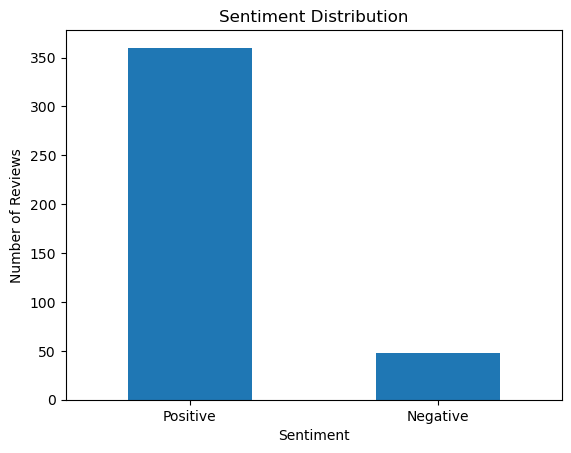

In [69]:
import matplotlib.pyplot as plt

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [55]:
 df["Ratings"].dtype   # correlation will not work in object so we will change the datatype

dtype('O')

In [57]:
df["Ratings"].value_counts()  

Ratings
5    374
4     31
3      2
2      1
Name: count, dtype: int64

In [59]:
type(df["Ratings"].iloc[0])   # it is str 

str

In [61]:
# changing to int 
df["Ratings"] = df["Ratings"].astype(int)

In [63]:
df["Ratings"].dtype

dtype('int32')

In [65]:
df[["Ratings", "Average_Polarity"]].corr()

,Ratings,Average_Polarity
Ratings,1.000000,0.009722
Average_Polarity,0.009722,1.000000


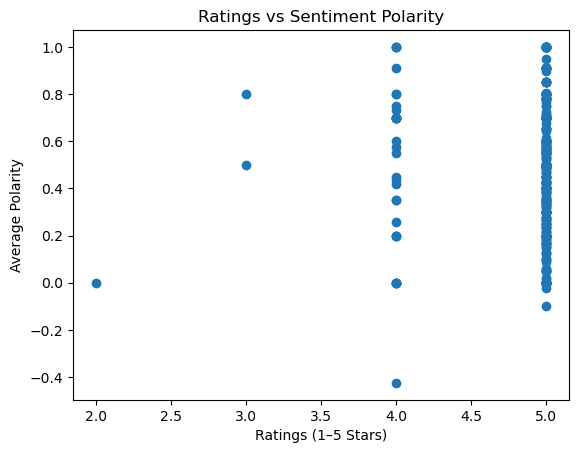

In [75]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["Ratings"], df["Average_Polarity"])

plt.title("Ratings vs Sentiment Polarity")
plt.xlabel("Ratings (1–5 Stars)")
plt.ylabel("Average Polarity")

plt.show()

In [ ]:
 # Investigate if longer reviews are associated with more detailed sentiments, either positive or negative.

In [93]:
#Compare Average Length by Sentiment
df.groupby("Sentiment")["Review_Length"].mean()

Sentiment
Negative    5.104167
Positive    8.175000
Name: Review_Length, dtype: float64

In [95]:
#Check Correlation (Length vs Polarity)
df[["Review_Length", "Average_Polarity"]].corr()

,Review_Length,Average_Polarity
Review_Length,1.00000,-0.22026
Average_Polarity,-0.22026,1.00000


In [98]:
df["Sentiment_Strength"] = df["Average_Polarity"].abs()

df[["Review_Length", "Sentiment_Strength"]].corr()

,Review_Length,Sentiment_Strength
Review_Length,1.000000,-0.213484
Sentiment_Strength,-0.213484,1.000000


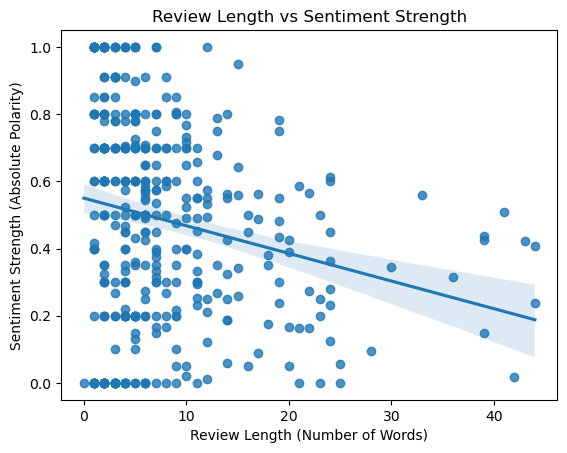

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.regplot(
    x="Review_Length",
    y="Sentiment_Strength",
    data=df
)

plt.title("Review Length vs Sentiment Strength")
plt.xlabel("Review Length (Number of Words)")
plt.ylabel("Sentiment Strength (Absolute Polarity)")

plt.show()



#  FlowerAura Rose Reviews – Sentiment Analysis Report

##  Overview of Data Collection and Cleaning Process

###  Data Source

The dataset consists of **FlowerAura Rose customer reviews** collected from the official website.

###  Data Extraction

* Web scraping was performed using **BeautifulSoup**.
* The extracted data was stored in a structured format using the **Pandas** library.

###  Data Cleaning Steps

* Checked for and removed duplicate reviews.
* Converted all review text to lowercase for consistency.
* Prepared the dataset for sentiment analysis by generating polarity scores.


## Sentiment Analysis Results

###  Sentiment Distribution

| Sentiment | Count | Percentage |
| --------- | ----- | ---------- |
| Positive  | 360   | 88.24%     |
| Negative  | 48    | 11.76%     |

###  Interpretation

* The majority of reviews (88.24%) are positive, indicating strong overall customer satisfaction.
* A smaller portion (11.76%) of reviews are negative, highlighting potential areas for improvement.
* The dataset is highly imbalanced toward positive reviews.


##  Review Length Analysis

###  Correlation Result

The correlation between **Review Length** and **Sentiment Strength** is:

**-0.213**

###  Interpretation

* This indicates a **weak negative relationship** between review length and emotional intensity.
* Longer reviews are not necessarily more emotionally intense.
* Shorter reviews tend to express stronger positive or negative emotions.
* Longer reviews appear more balanced and descriptive, often including mixed feedback.



##  Overall Conclusion

The sentiment analysis reveals that customer perception of FlowerAura Rose products is predominantly positive. While review length shows a weak relationship with sentiment intensity, it is not a strong predictor of emotional strength.

These findings suggest that although customers are generally satisfied, analyzing negative feedback in detail can help identify operational improvements and enhance overall service quality.


